In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Load json file containing jazz songs as a dataframe to see what it looks like

with open("../data/JazzStandards_raw.json", "r") as file:
    data = pd.read_json(file)

data.head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key
0,9.20 Special,Earl Warren,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'D9|...",NaN
1,26-2,John Coltrane,Medium Up Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fma...",F
2,52nd Street Theme,Thelonious Monk,Up Tempo Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN
3,500 Miles High,Chick Corea,Bossa Nova,4/4,[{'MainSegment': {'Chords': 'Em7|Em7|Gm7|Gm7|B...,Emin
4,502 Blues,Jimmy Rowles,Waltz,3/4,[{'MainSegment': {'Chords': 'Am7|Dbmaj7|Bm7b5|...,Amin


In [3]:
data.shape

(1382, 6)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          1382 non-null   object
 1   Composer       1382 non-null   object
 2   Rhythm         1382 non-null   object
 3   TimeSignature  1371 non-null   object
 4   Sections       1382 non-null   object
 5   Key            1149 non-null   object
dtypes: object(6)
memory usage: 64.9+ KB


In [5]:
# Scrape song composition years from wikipedia/google both manually and using ChatGPT. compile as a list
# If no composition year available, release year is used
song_years = [1941, 1960, 1947, 1972, 1958, 1946, 1942, 1954, 1958, 1965, 1958, 1936, 1957, 1937, 1931, 1935, 1960, 1943, 1942, 1939, 1919, 1974, 1954, 1941, 1982, 1946, 1961, 1966, 1938, 1960, 1955, 1944, 1946, 1974, 1977, 1962, 1951, 1959, 1973, 1979, 1918, 1949, 1948, 1959, 2006, 1929, 1927, 1954, 1941, 1966, 1911, 1963, 1966, 1865, 1945, 1924, 1955, 1959, 1921, 1937, 1959, 1939, 1931, 1954, 1939, 1939, 1838, 1946, 1942, 1940, 1947, 1932, 1924, 1958, 1985, 1992, 1929, 1927, 1959, 1973, 1944, 1946, 1946, 1934, 1969, 1932, 1982, 1952, 1945, 1817, 1941, 1946, 1931, 1951, 1941, 1938, 1951, 1934, 1947, 1941, 1920, 1959, 1919, 1959, 1961, 1952, 1998, 1956, 1946, 1942, 1956, 2023, 1954, 1928, 1946, 1953, 1942, 1950, 1945, 1964, 1931, 1889, 1935, 1970, 1955, 2005, 1952, 1932, 1959, 1964, 1959, 1959, 1950, 1927, 1989, 1959, 1963, 1902, 1964, 1930, 1943, 1930, 1922, 1902, 1962, 1945, 1912, 1951, 1926, 1929, 1927, 1940, 1929, 1947, 1964, 1976, 1934, 1967, 1950, 1922, 1961, 1963, 1941, 1960, 1959, 1945, 1954, 1937, 1926, 1957, 1927, 1971, 1929, 1940, 1959, 1963, 1951, 1961, 1921, 1941, 1958, 1963, 1930, 1955, 1966, 1967, 1961, 1957, 1946, 1964, 1933, 1946, 1949, 1944, 1939, 1968, 1954, 1928, 1955, 1962, 1973, 1957, 1926, 1932, 1961, 1924, 1949, 1914, 1947, 1930, 1957, 1966, 1973, 1937, 1965, 1926, 1925, 1963, 1942, 1953, 1947, 1958, 1943, 1965, 1962, 1927, 1929, 1953, 1964, 1972, 1936, 1963, 1949, 1960, 1965, 1973, 1938, 1923, 1947, 1926, 1935, 1948, 1959, 1957, 1958, 1941, 1938, 1947, 1922, 1969, 1966, 1979, 1979, 1933, 1969, 1814, 1957, 1946, 1943, 1939, 1971, 1956, 1954, 1972, 1946, 1968, 1975, 1959, 1807, 1959, 1962, 1964, 1929, 1940, 1943, 1959, 1977, 1858, 1949, 1928, 1928, 1959, 1968, 1949, 1953, 1972, 1939, 1964, 1946, 1954, 1966, 1924, 1931, 1930, 1913, 1939, 1960, 1945, 1946, 1965, 1939, 1972, 1946, 1967, 1962, 1872, 1822, 1953, 1957, 1950, 1926, 1968, 1960, 1959, 1959, 1948, 1956, 1947, 1947, 1939, 1986, 1954, 1925, 1959, 1964, 1954, 1922, 1940, 1947, 1959, 1965, 1970, 1946, 1934, 1932, 1956, 1934, 1940, 1960, 1999, 1968, 1941, 1938, 1947, 1918, 1941, 1936, 1954, 1936, 1930, 1941, 1958, 1945, 1899, 1963, 1965, 1946, 1934, 1926, 1947, 1949, 1930, 1954, 1934, 1952, 1977, 1968, 1965, 1985, 1965, 1949, 1930, 1964, 1950, 1959, 1942, 1965, 1963, 1965, 1957, 1944, 1966, 1940, 1933, 1941, 1942, 1951, 1930, 1964, 1959, 1965, 1930, 1938, 1895, 1924, 1922, 1962, 1890, 1940, 1977, 1957, 1930, 1939, 1974, 1949, 1959, 1941, 1938, 1960, 1954, 1939, 1937, 1940, 1964, 1934, 1950, 1840, 1958, 1965, 1941, 1936, 1966, 1992, 1954, 1948, 1951, 1960, 1957, 1959, 1959, 1955, 1939, 1963, 1945, 1950, 1962, 1957, 1956, 1935, 1964, 1929, 1969, 1963, 1930, 1927, 1956, 1938, 1959, 1963, 1965, 1945, 1936, 1961, 1935, 1939, 1949, 1961, 1939, 1944, 1962, 1946, 1918, 1959, 1986, 1959, 1956, 1966, 1964, 1944, 1990, 1953, 1873, 1956, 1947, 1943, 1953, 1947, 1943, 1948, 1937, 1955, 1917, 1933, 1966, 1826, 1964, 1951, 1953, 1975, 1990, 1951, 1954, 1975, 1937, 1958, 1959, 1963, 1970, 1957, 1994, 1929, 1960, 1945, 1964, 1941, 1947, 1932, 1940, 1963, 1944, 1928, 1962, 1870, 1955, 1915, 1952, 1926, 1935, 1928, 1940, 1956, 1940, 1933, 1923, 1944, 1939, 1945, 1961, 1944, 1956, 1926, 1934, 1938, 1941, 1930, 1946, 1932, 1944, 1929, 1938, 1963, 1941, 1940, 1953, 1938, 1933, 1961, 1953, 1918, 1935, 1929, 1951, 1934, 1957, 1946, 1937, 1944, 1931, 1941, 1939, 1938, 1925, 1944, 1938, 1964, 1963, 1963, 1937, 1943, 1942, 1938, 1945, 1928, 1932, 1939, 1913, 1941, 1924, 1956, 1951, 1961, 1917, 1936, 1944, 1930, 1932, 1941, 1960, 1935, 1935, 1945, 1942, 1936, 1925, 1931, 1926, 1930, 1937, 1932, 1936, 1956, 1942, 1950, 1930, 1963, 1958, 1926, 1939, 1928, 1966, 1945, 1963, 1936, 1950, 1934, 1946, 1937, 1963, 1937, 1936, 1961, 1926, 1940, 1935, 1932, 1969, 1987, 1937, 1972, 1951, 1935, 1937, 1955, 1947, 1955, 1946, 1938, 1851, 1917, 1964, 1964, 1963, 1970, 1952, 1966, 1933, 1966, 1943, 1959, 1963, 1970, 1932, 1935, 1913, 1956, 1935, 1944, 1932, 1924, 1945, 1940, 1948, 1948, 1902, 1955, 1946, 1946, 1950, 1961, 1953, 1945, 1936, 1935, 1968, 1987, 1947, 1933, 1933, 1963, 1951, 1951, 1940, 1966, 1954, 1965, 1960, 1938, 1942, 1959, 1942, 1966, 1940, 1953, 1959, 1954, 1966, 1909, 1929, 1941, 1931, 1956, 1946, 1931, 1935, 1941, 1929, 1927, 1981, 1898, 1959, 1968, 1945, 1964, 1971, 1945, 1939, 1947, 1955, 1956, 1939, 1977, 1958, 1937, 1935, 1954, 1987, 1945, 1960, 1955, 1958, 1930, 1931, 1976, 1946, 1931, 1949, 1940, 1956, 1937, 1937, 1958, 1928, 1936, 1928, 1941, 1943, 1957, 1915, 1965, 1965, 1944, 1926, 1946, 1967, 1921, 1952, 1923, 1966, 1942, 1967, 1874, 1935, 1958, 1990, 1951, 1964, 1847, 1947, 1929, 1955, 1862, 1933, 1955, 1927, 1944, 1964, 1919, 1967, 1966, 1967, 1985, 1971, 1951, 1934, 1932, 1955, 1951, 1966, 1930, 1930, 1942, 1928, 1935, 1954, 1952, 1932, 1935, 1949, 1963, 1990, 1928, 1964, 1965, 1960, 1928, 1911, 1924, 1954, 1959, 1898, 1945, 1959, 1962, 1939, 1946, 1965, 1946, 1989, 1929, 1957, 1962, 1969, 1930, 1966, 1915, 1967, 1939, 1954, 1957, 1958, 1958, 1946, 1982, 1978, 1961, 1955, 1960, 1953, 1980, 1948, 1954, 1967, 1958, 1955, 1949, 1963, 1947, 1930, 1941, 1941, 1958, 1961, 1970, 1970, 1933, 1942, 1943, 1931, 1939, 1974, 1946, 1945, 1929, 1964, 1965, 1935, 1926, 1948, 1959, 1930, 1922, 1959, 1949, 1937, 1938, 1927, 1930, 1936, 1915, 1955, 1928, 1935, 1912, 1934, 1952, 1935, 1986, 1943, 1941, 1977, 1969, 1977, 1959, 1942, 1958, 1996, 1947, 1938, 1967, 1953, 1960, 1931, 1985, 1977, 1956, 1960, 1937, 1964, 1946, 1964, 1948, 1941, 1922, 1947, 1957, 1946, 1923, 1959, 1987, 1945, 1940, 1954, 1958, 1964, 1968, 1947, 1924, 1943, 1962, 1925, 1957, 1960, 1947, 1851, 1954, 1964, 1965, 1956, 1948, 1962, 1947, 1956, 1930, 1964, 1961, 1937, 1962, 1962, 1964, 1960, 1943, 1924, 1930, 1961, 1905, 1946, 1962, 1961, 1950, 1946, 1947, 1937, 1931, 1945, 1939, 1934, 1894, 1913, 1939, 1951, 1948, 1956, 1967, 1946, 1920, 1960, 1974, 1967, 1933, 1970, 1936, 1962, 1956, 1955, 1963, 1943, 1942, 1935, 1947, 1960, 1958, 1961, 1978, 1936, 1961, 1963, 1883, 1959, 1932, 1940, 1916, 1975, 1948, 1959, 1938, 1952, 1967, 1979, 1949, 1957, 1971, 1960, 1927, 1831, 1977, 1989, 1969, 1886, 1979, 1870, 1974, 1914, 1957, 1970, 1944, 1953, 1960, 1946, 1926, 1932, 1968, 1968, 1929, 1954, 1917, 1939, 1944, 1926, 1947, 1962, 1927, 1960, 1972, 1989, 1941, 1959, 1929, 1955, 1964, 1953, 1955, 1940, 1994, 1946, 1949, 1947, 1971, 1967, 1951, 1961, 1916, 1955, 1944, 1937, 1938, 1968, 1968, 1959, 1964, 1952, 1939, 1963, 1965, 1945, 1928, 1910, 1928, 1960, 1960, 1956, 1963, 1977, 1945, 1947, 1959, 1952, 1942, 1947, 1946, 1962, 1959, 1933, 1934, 1979, 1963, 1948, 1967, 1964, 1964, 1959, 1955, 1928, 1954, 1930, 1949, 1962, 1970, 1944, 1924, 1937, 1967, 1926, 1962, 1927, 1957, 1965, 1972, 1933, 1932, 1959, 1929, 1933, 1966, 1957, 1958, 1953, 1971, 1968, 1943, 1964, 1959, 1955, 1938, 1928, 1914, 1956, 1938, 1935, 1927, 1943, 1957, 1934, 1944, 1961, 1936, 1933, 1966, 1951, 1962, 1943, 1966, 1932, 1940, 1960, 1901, 1949, 1947, 1926, 1978, 1972, 1971, 1935, 1980, 1965, 1935, 1966, 1962, 1946, 1943, 1879, 1969, 1931, 1964, 1925, 1928, 1928, 1962, 1963, 1910, 1957, 1959, 1941, 1940, 1944, 1921, 1925, 1953, 1969, 1949, 1946, 1956, 1938, 1937, 1944, 1952, 1953, 1963, 1917, 1930, 1999, 1962, 1936, 1942, 1921, 1937, 1937, 1944, 1936, 1937, 1937, 1914, 1946, 1942, 1946, 1954, 1938, 1956, 1960, 1958, 1941, 1972, 1941, 1936, 1927, 1963, 1950, 1951, 1949, 1953, 1957, 1946, 1930, 1962, 1948, 1958, 1958, 1941, 1962, 1966, 1957, 1966, 1926, 1956, 1937, 1951, 1944, 1852, 1936, 1954, 1946, 1946, 1946, 1956, 1982, 1953, 1954, 1966, 1946, 1932, 1953, 1966, 1957, 1949, 1965, 1967, 1949, 1938, 1967, 1938, 1933, 1951, 1964, 1881, 1976, 1970, 1962, 1943, 1905, 1956, 1962, 1934, 1941, 1946, 1986, 1942, 1967, 1957, 1930, 1952, 1957, 1956, 1940, 1964, 1963, 1963, 1936, 1995, 1954, 1977, 1945, 1840, 1944, 1975, 1960, 1934, 1934, 1967, 1947, 1969, 1929, 1923, 1939, 1952, 2001, 1931, 1907, 1956, 1900, 1941, 1940, 1926, 1931, 1969, 1937, 1943, 1956, 1964, 1927, 1923, 1926, 1941, 1964, 1932, 1932, 1966, 1964, 1956, 1929, 1930, 1929, 1929, 1942, 1966, 1956, 1946, 1931, 1946, 1964, 1942, 1933, 1941, 1930, 1947, 1946, 1930, 1939, 1931, 1941, 1930, 1946, 1914, 1955, 1969, 1940, 1928, 1936, 1946, 1934, 1934, 1972, 1937, 1934, 1936, 1949, 1930, 1935, 1940, 1954, 1909, 1928, 1967, 1965]

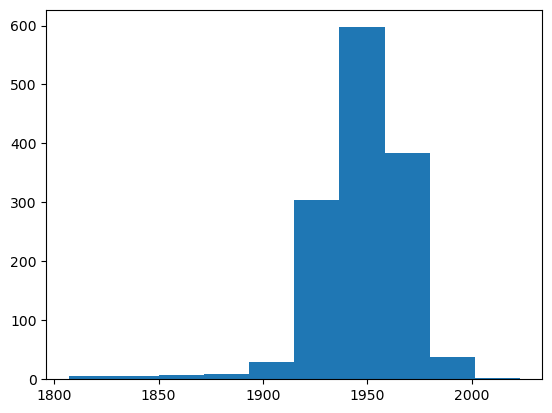

In [6]:
plt.hist(song_years)
plt.show()

In [7]:
#Create a Year column in our dataframe from our web-scraped list
data['Year'] = song_years

In [8]:
data.head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year
0,9.20 Special,Earl Warren,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'D9|...",NaN,1941
1,26-2,John Coltrane,Medium Up Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fma...",F,1960
2,52nd Street Theme,Thelonious Monk,Up Tempo Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN,1947
3,500 Miles High,Chick Corea,Bossa Nova,4/4,[{'MainSegment': {'Chords': 'Em7|Em7|Gm7|Gm7|B...,Emin,1972
4,502 Blues,Jimmy Rowles,Waltz,3/4,[{'MainSegment': {'Chords': 'Am7|Dbmaj7|Bm7b5|...,Amin,1958


In [9]:
data.drop(columns=["Sections"], inplace=True)

In [10]:
#save this dataframe as song_data_cleaned
song_data = data

In [11]:
#create new dataframe with one row per chord by splitting sections into individual chords

with open("../data/JazzStandards_raw.json", "r") as file:
    data = json.load(file)

master_chord_list = []

for i, song in enumerate(data):
    title = song.get("Title")
    composer = song.get("Composer")
    key = song.get("Key", "")
    rhythm = song.get("Rhythm")
    time_signature = song.get("TimeSignature")
    sections = song.get("Sections")
    year = song_years[i]  

    chord_counter = 0  

    for section in sections:
        label = section.get("Label")
        main_segment = section.get("MainSegment")
        chord_str = main_segment.get("Chords")
        endings = section.get("Endings", [])
        for ending in endings:
            chord_str += ("|" + ending.get("Chords"))
    
        measures = chord_str.split('|')

        for measure_ind, measure in enumerate(measures):
            chords = measure.split(",")
            for chord in chords:
                master_chord_list.append({
                    "Title": title,
                    "Composer": composer,
                    "Key": key,
                    "Rhythm": rhythm,
                    "Time Signature": time_signature,
                    "Section": label,
                    "Measure": measure_ind,
                    "Chord Index": chord_counter,
                    "Chord": chord.strip(),
                    "Year": year
                })
                chord_counter += 1 

df = pd.DataFrame(master_chord_list)

In [12]:
df.iloc[30:41]

,Title,Composer,Key,Rhythm,Time Signature,Section,Measure,Chord Index,Chord,Year
30,9.20 Special,Earl Warren,,Medium Swing,4/4,A,5,30,C7,1941
31,9.20 Special,Earl Warren,,Medium Swing,4/4,A,5,31,B7,1941
32,9.20 Special,Earl Warren,,Medium Swing,4/4,A,5,32,Bb7,1941
33,9.20 Special,Earl Warren,,Medium Swing,4/4,A,5,33,A7,1941
34,9.20 Special,Earl Warren,,Medium Swing,4/4,A,6,34,D9,1941
35,9.20 Special,Earl Warren,,Medium Swing,4/4,A,7,35,G7,1941
36,9.20 Special,Earl Warren,,Medium Swing,4/4,A,7,36,C6,1941
37,26-2,John Coltrane,F,Medium Up Swing,4/4,A,0,0,Fmaj7,1960
38,26-2,John Coltrane,F,Medium Up Swing,4/4,A,0,1,Ab7,1960
39,26-2,John Coltrane,F,Medium Up Swing,4/4,A,1,2,Dbmaj7,1960


In [13]:
# Each row in the DataFrame represents a single chord. 
# Notice that when the DataFrame reaches a new song (e.g. row 37), 
# the "Chord Index" resets to 0 while all other metadata remains consistent for each chord.
# Sections and Measures change properly as well

In [14]:
chord_data = df

In [15]:
#save df to directory
chord_data.to_csv('../data/chord_data_cleaned.csv', index=False)

In [16]:
#save song data (not by chord) separately
song_data.to_csv('../data/song_data_cleaned.csv', index=False)